# B-plane Targeting Demo: OSIRIS-REx 2017 Earth Gravity Assist

This notebook demonstrates a B-plane targeting workflow using the OSIRIS-REx 2017 Earth gravity assist.

The workflow is:

1. Load the required SPICE kernels.
2. Define the closest-approach and TCM epochs.
3. Build a B-plane object for the Earth encounter.
4. Compute the reference B-plane target.
5. Inject a navigation error at the TCM epoch.
6. Compute corrective TCMs using linear and nonlinear targeting.
7. Map state covariance into B-plane uncertainty.

## Imports

Import Scarabaeus, NumPy, and set up the helper path used by the tutorial data loader.

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import scarabaeus as scb

# Make the tutorials helper module importable both from scripts and notebooks.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

sys.path.insert(0, str(NOTEBOOK_DIR / ".." / ".." / "tutorials"))

## Setup and SPICE kernels

Load the tutorial data and the SPICE kernels required for the OSIRIS-REx Earth flyby example.

In [2]:
km, sec = scb.Units.get_units(["km", "sec"])

# Load spice kernels
import supplementary as supp

data = supp.load_data()
from pathlib import Path
import os

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()

    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() or (path / ".git").exists():
            return path

    raise FileNotFoundError("Could not find repo root from current notebook path.")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"

assert DATA_DIR.exists(), f"Data folder not found at {DATA_DIR}"

scb.SpiceManager.clear_kernels()

scb.SpiceManager.load_kernel_from_mkfile(
    str(DATA_DIR / "kernels" / "locked" / "locked_generic.tm")
)

scb.SpiceManager.load_kernel(
    str(DATA_DIR / "kernels" / "scenario" / "orx_160909_171201_170830_od023_v1.bsp")
)

scb.SpiceManager.print_kernels()

SCB tutorial data up to date.
                                 Kernels Loaded:
Source:   /Users/zael5647/scarabaeus/data/kernels/locked/locked_generic.tm   (META)
Source:   data/kernels/locked/ck/cas00084.tsc   (TEXT)
Source:   data/kernels/locked/lsk/naif0012.tls   (TEXT)
Source:   data/kernels/locked/spk/de432s.bsp   (SPK)
Source:   data/kernels/locked/pck/pck00010.tpc   (TEXT)
Source:   data/kernels/locked/pck/gm_de431.tpc   (TEXT)
Source:   data/kernels/locked/spk/earthstns_fx_201023.bsp   (SPK)
Source:   data/kernels/locked/spk/earth_200101_990628_predict.bpc   (PCK)
Source:   data/kernels/locked/spk/earth_topo_201023.tf   (TEXT)
Source:   /Users/zael5647/scarabaeus/data/kernels/scenario/orx_160909_171201_170830_od023_v1.bsp   (SPK)


## Epoch definition

Define the closest-approach epoch and a TCM epoch roughly 30 days before closest approach.

In [3]:
#     Closest approach: 2017-SEP-22  ~16:52 UTC
#     TCM epoch:        30 days prior
# =======================================================

time_ca = scb.SpiceManager.str2et("2017-SEP-22 16:52:00.000 UTC")
time_tcm = scb.SpiceManager.str2et("2017-AUG-23 00:00:00.000 UTC")

epoch_ca = scb.EpochArray(time_ca, sys="TDB")
epoch_tcm = scb.EpochArray(time_tcm, sys="TDB")

## Reference state at the TCM epoch

Load the reference OSIRIS-REx state relative to the Earth barycenter in J2000.

In [4]:
# =======================================================

state_ref_tcm = scb.SpiceManager.get_state(
    trgt_bdy="-64",
    epoch_time=epoch_tcm.times.values,
    reference_frame="J2000",
    obsvr_bdy="3",
)

## Construct the B-plane object

Create the B-plane object associated with the Earth encounter. This object handles the B-plane frame and targeting utilities.

In [5]:
#     Built from the clean reference state → bpar_ref is
#     the desired target the TCM must recover.
# =======================================================

bplane_file = os.getcwd() + "/data/kernels/OREX_EARTH_bplane.tf"
if os.path.exists(bplane_file):
    os.remove(bplane_file)

BplaneObj = scb.Bplane(
    epoch=epoch_tcm,
    bplane_name="OREX_EARTH_BPLANE",
    bplane_spice_id=12345678,
    sc_name="OSIRIS-REx",
    sc_spice_id=-64,
    target_name="EARTHBARYCENTER",
    target_spice_id=3,
    fk_file=bplane_file,
    v_hat=False,
    new_bplane=True,
)

print()
print("#" * 80)
print("  B-plane targeting demo  —  OSIRIS-REx Earth gravity assist 2017")
print("#" * 80)


################################################################################
  B-plane targeting demo  —  OSIRIS-REx Earth gravity assist 2017
################################################################################


## Reference B-plane target

Compute the desired B-plane parameters from the clean reference trajectory.

In [6]:
bpar_ref = BplaneObj.compute_parameters(sc_rel_state_j2000=state_ref_tcm)

print("\n[TARGET]  Desired B-plane parameters (reference trajectory):")
print(f"  B·T*  = {bpar_ref.values[0]:>16.3f}  km")
print(f"  B·R*  = {bpar_ref.values[1]:>16.3f}  km")
print(
    f"  |B|   = {np.linalg.norm(bpar_ref.values[:2]):>16.3f}  km  (miss distance proxy)"
)
print(
    f"  ltof* = {bpar_ref.values[2]:>16.3f}  s  "
    f"({bpar_ref.values[2] / 86400:.2f} days to closest approach)"
)


[TARGET]  Desired B-plane parameters (reference trajectory):
  B·T*  =      1328001.381  km
  B·R*  =      -578613.927  km
  |B|   =      1448579.215  km  (miss distance proxy)
  ltof* =     -2376484.783  s  (-27.51 days to closest approach)


## Inject a navigation error

Perturb the reference state with a representative cruise OD error and inspect the resulting B-plane miss.

In [7]:
#     Realistic 1-sigma OD uncertainty for deep-space cruise:
#       position  ~ 10 km
#       velocity  ~ 1 cm/s  (1e-5 km/s)
# =======================================================

np.random.seed(7)
pos_1sigma = 10.0  # km
vel_1sigma = 1e-5  # km/s

nav_error = scb.ArrayWUnits(
    np.array(
        [
            pos_1sigma * np.random.randn(),
            pos_1sigma * np.random.randn(),
            pos_1sigma * np.random.randn(),
            vel_1sigma * np.random.randn(),
            vel_1sigma * np.random.randn(),
            vel_1sigma * np.random.randn(),
        ]
    ),
    [km, km, km, km / sec, km / sec, km / sec],
)

state_pert_tcm = state_ref_tcm + nav_error

bpar_pert = BplaneObj.compute_parameters(sc_rel_state_j2000=state_pert_tcm)

print("\n[PERTURBED]  B-plane parameters after navigation error:")
print(
    f"  B·T   = {bpar_pert.values[0]:>16.3f}  km   "
    f"(error: {bpar_pert.values[0] - bpar_ref.values[0]:+.3f} km)"
)
print(
    f"  B·R   = {bpar_pert.values[1]:>16.3f}  km   "
    f"(error: {bpar_pert.values[1] - bpar_ref.values[1]:+.3f} km)"
)
print(
    f"  ltof  = {bpar_pert.values[2]:>16.3f}  s    "
    f"(error: {bpar_pert.values[2] - bpar_ref.values[2]:+.3f} s)"
)
print(f"  |B|   = {np.linalg.norm(bpar_pert.values[:2]):>16.3f}  km")


[PERTURBED]  B-plane parameters after navigation error:
  B·T   =      1327978.467  km   (error: -22.914 km)
  B·R   =      -578614.221  km   (error: -0.294 km)
  ltof  =     -2376488.408  s    (error: -3.625 s)
  |B|   =      1448558.326  km


## Linear targeting

Compute a corrective TCM using the local B-plane Jacobian/Newton iteration.

In [8]:
print("\n" + "#" * 80)
print("  Linear targeting  (Newton iteration on Jacobian)")
print("#" * 80)

DV_lin = BplaneObj.linear_targeting(sc_rel_state_j2000=state_pert_tcm)

state_corr_lin = scb.ArrayWUnits(
    np.concatenate(
        [
            state_pert_tcm[0:3].values,
            state_pert_tcm[3:6].values + DV_lin.values,
        ]
    ),
    [km, km, km, km / sec, km / sec, km / sec],
)
bpar_corr_lin = BplaneObj.compute_parameters(state_corr_lin)

print(
    f"\n  TCM ΔV  =  [{DV_lin.values[0]:+.8f},  "
    f"{DV_lin.values[1]:+.8f},  {DV_lin.values[2]:+.8f}]  km/s"
)
print(f"  |ΔV|   =  {np.linalg.norm(DV_lin.values) * 1e3:.6f}  m/s")
print(f"\n  Post-TCM residuals:")
print(f"  ΔB·T  = {bpar_corr_lin.values[0] - bpar_ref.values[0]:+.2e}  km")
print(f"  ΔB·R  = {bpar_corr_lin.values[1] - bpar_ref.values[1]:+.2e}  km")
print(f"  Δltof = {bpar_corr_lin.values[2] - bpar_ref.values[2]:+.2e}  s")


################################################################################
  Linear targeting  (Newton iteration on Jacobian)
################################################################################
linear_targeting converged in 2 iterations. Residual = 0.000e+00

  TCM ΔV  =  [-0.00000733,  +0.00023558,  +0.00009824]  km/s
  |ΔV|   =  0.255350  m/s

  Post-TCM residuals:
  ΔB·T  = +5.37e+02  km
  ΔB·R  = -2.34e+02  km
  Δltof = +0.00e+00  s


## Nonlinear targeting

Compute a corrective TCM using nonlinear optimization and compare it to the linear result.

In [9]:
print("\n" + "#" * 80)
print("  Nonlinear targeting  (Nelder-Mead)")
print("#" * 80)

DV_nl = BplaneObj.nonlinear_targeting(sc_rel_state_j2000=state_pert_tcm)

state_corr_nl = scb.ArrayWUnits(
    np.concatenate(
        [
            state_pert_tcm[0:3].values,
            state_pert_tcm[3:6].values + DV_nl.values,
        ]
    ),
    [km, km, km, km / sec, km / sec, km / sec],
)
bpar_corr_nl = BplaneObj.compute_parameters(state_corr_nl)

print(
    f"\n  TCM ΔV  =  [{DV_nl.values[0]:+.8f},  "
    f"{DV_nl.values[1]:+.8f},  {DV_nl.values[2]:+.8f}]  km/s"
)
print(f"  |ΔV|   =  {np.linalg.norm(DV_nl.values) * 1e3:.6f}  m/s")
print(f"\n  Post-TCM residuals:")
print(f"  ΔB·T  = {bpar_corr_nl.values[0] - bpar_ref.values[0]:+.2e}  km")
print(f"  ΔB·R  = {bpar_corr_nl.values[1] - bpar_ref.values[1]:+.2e}  km")
print(f"  Δltof = {bpar_corr_nl.values[2] - bpar_ref.values[2]:+.2e}  s")


################################################################################
  Nonlinear targeting  (Nelder-Mead)
################################################################################
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 118
         Function evaluations: 219

  TCM ΔV  =  [-0.00000733,  +0.00023558,  +0.00009824]  km/s
  |ΔV|   =  0.255350  m/s

  Post-TCM residuals:
  ΔB·T  = +5.37e+02  km
  ΔB·R  = -2.34e+02  km
  Δltof = +1.10e-06  s


## Compare TCM solutions

Compare the magnitude of the linear and nonlinear TCMs.

In [10]:
print("\n" + "#" * 80)
print("  TCM comparison")
print("#" * 80)
print(f"  |ΔV| linear     =  {np.linalg.norm(DV_lin.values) * 1e3:.6f}  m/s")
print(f"  |ΔV| nonlinear  =  {np.linalg.norm(DV_nl.values)  * 1e3:.6f}  m/s")
print(
    f"  |difference|    =  "
    f"{np.linalg.norm(DV_lin.values - DV_nl.values) * 1e3:.2e}  m/s"
)


################################################################################
  TCM comparison
################################################################################
  |ΔV| linear     =  0.255350  m/s
  |ΔV| nonlinear  =  0.255350  m/s
  |difference|    =  4.24e-09  m/s


## Covariance mapping

Map a diagonal OD covariance into B-plane uncertainty.

In [11]:
#     Diagonal OD covariance consistent with the 1-sigma
#     values used to generate the navigation error above.
# =======================================================

print("\n" + "#" * 80)
print("  Covariance analysis")
print("#" * 80)

sv_cov = np.diag(
    [
        pos_1sigma**2,
        pos_1sigma**2,
        pos_1sigma**2,
        vel_1sigma**2,
        vel_1sigma**2,
        vel_1sigma**2,
    ]
)

P_bplane = BplaneObj.target_covariance(sv_cov, sc_rel_state_j2000=state_pert_tcm)

sigma_bt = np.sqrt(P_bplane.values[0, 0])
sigma_br = np.sqrt(P_bplane.values[1, 1])
sigma_ltof = np.sqrt(P_bplane.values[2, 2])

print(f"\n  1-sigma B-plane uncertainties mapped from OD covariance:")
print(f"  σ(B·T)  =  {sigma_bt:.4f}  km")
print(f"  σ(B·R)  =  {sigma_br:.4f}  km")
print(f"  σ(ltof) =  {sigma_ltof:.4f}  s")


################################################################################
  Covariance analysis
################################################################################

  1-sigma B-plane uncertainties mapped from OD covariance:
  σ(B·T)  =  10.0000  km
  σ(B·R)  =  10.0000  km
  σ(ltof) =  3.4594  s


## Plot B-plane covariance

Plot the mapped B-plane covariance ellipse.

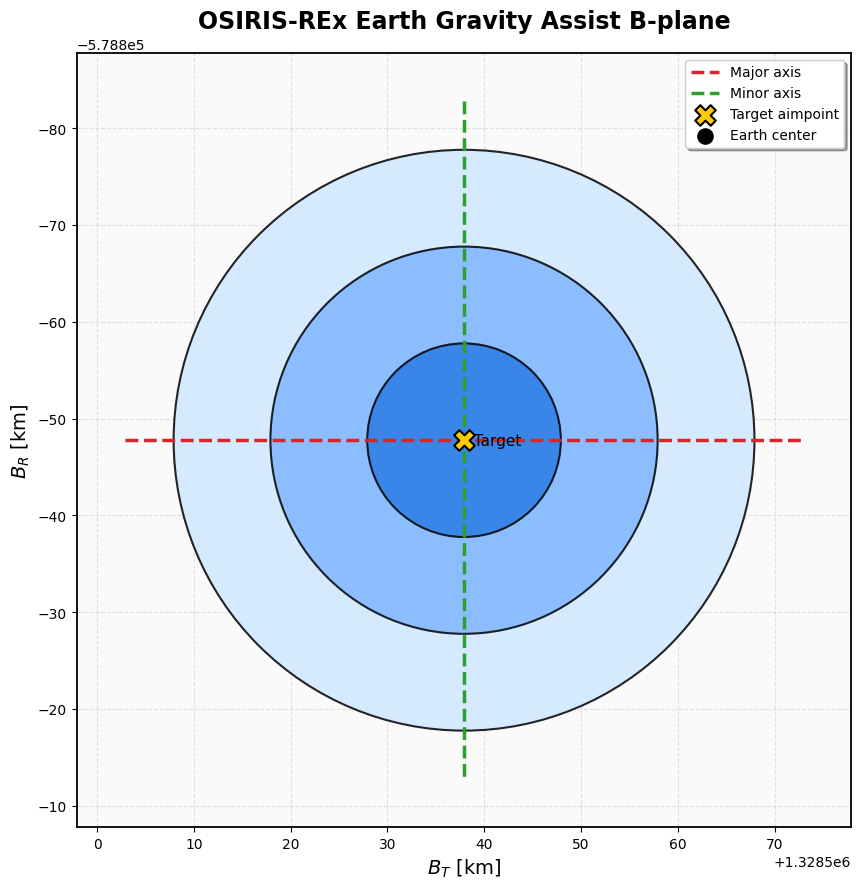

In [12]:
# ============================================================
# Fancy custom B-plane covariance plot
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Extract covariance matrix
P = P_bplane[:2, :2].values

# Target coordinates
bt = float(BplaneObj._bt_ref.values)
br = float(BplaneObj._br_ref.values)

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(P)

# Sort largest first
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Ellipse angle
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

# Background style
ax.set_facecolor("#fafafa")

# Sigma ellipses
sigmas = [3, 2, 1]
colors = ["#cfe8ff", "#7fb6ff", "#2c7be5"]

for nsig, color in zip(sigmas, colors):

    width = 2 * nsig * np.sqrt(eigvals[0])
    height = 2 * nsig * np.sqrt(eigvals[1])

    ell = Ellipse(
        (bt, br),
        width,
        height,
        angle=angle,
        facecolor=color,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.85,
        zorder=2,
    )

    ax.add_patch(ell)

# Principal directions
major = eigvecs[:, 0]
minor = eigvecs[:, 1]

Lmaj = 3.5 * np.sqrt(eigvals[0])
Lmin = 3.5 * np.sqrt(eigvals[1])

ax.plot(
    [bt - Lmaj * major[0], bt + Lmaj * major[0]],
    [br - Lmaj * major[1], br + Lmaj * major[1]],
    "--",
    lw=2.5,
    color="#d62728",
    label="Major axis",
)

ax.plot(
    [bt - Lmin * minor[0], bt + Lmin * minor[0]],
    [br - Lmin * minor[1], br + Lmin * minor[1]],
    "--",
    lw=2.5,
    color="#2ca02c",
    label="Minor axis",
)

# Target point
ax.scatter(
    bt,
    br,
    s=220,
    marker="X",
    color="#ffcc00",
    edgecolor="black",
    linewidth=1.5,
    zorder=10,
    label="Target aimpoint",
)

# Small Earth marker at origin
ax.scatter(
    0,
    0,
    s=120,
    color="black",
    marker="o",
    zorder=8,
    label="Earth center",
)

# ============================================================
# Labels / style
# ============================================================

ax.set_title(
    "OSIRIS-REx Earth Gravity Assist B-plane",
    fontsize=17,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(r"$B_T$ [km]", fontsize=14)
ax.set_ylabel(r"$B_R$ [km]", fontsize=14)

# Equal aspect
ax.set_aspect("equal", adjustable="box")

# Invert R axis (standard B-plane convention)
ax.invert_yaxis()

# Grid
ax.grid(True, linestyle="--", alpha=0.35)

# Dynamic limits
maxsig = 4 * np.sqrt(np.max(eigvals))

ax.set_xlim(bt - maxsig, bt + maxsig)
ax.set_ylim(br + maxsig, br - maxsig)

# Pretty frame
for spine in ax.spines.values():
    spine.set_linewidth(1.3)

# Legend
leg = ax.legend(
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True,
)

# Optional annotation
ax.text(
    bt,
    br,
    "  Target",
    fontsize=11,
    verticalalignment="center",
)

plt.tight_layout()
plt.show()

## Notes

- The B-plane target is defined by the reference trajectory. The injected navigation error represents a possible OD error at the TCM epoch.
- Linear targeting should be accurate when the perturbation is small enough for the B-plane mapping to remain locally linear.
- The covariance mapping gives the predicted residual B-plane uncertainty from the assumed state covariance.